## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.gridspec as gridspec
import itertools
from mlxtend.plotting import plot_decision_regions

In [116]:
data = pd.read_csv('penguins_data.csv')
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [117]:
missing_values = data.isnull().sum()
print(missing_values)

Species                 0
Island                  0
Clutch Completion       0
Date Egg                0
Culmen Length (mm)      2
Culmen Depth (mm)       2
Flipper Length (mm)     2
Body Mass (g)           2
Sex                    10
Delta 15 N (o/oo)      14
Delta 13 C (o/oo)      13
dtype: int64


In [118]:
data = data.dropna()

In [119]:
missing_values = data.isnull().sum()
print(missing_values)

Species                0
Island                 0
Clutch Completion      0
Date Egg               0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
Delta 15 N (o/oo)      0
Delta 13 C (o/oo)      0
dtype: int64


In [120]:
rows_with_dot = data[data['Sex'] == '.']
rows_with_dot

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
41,Gentoo,Biscoe,Yes,0,44.5,15.7,217.0,4875.0,.,8.04111,-26.18444


В датасете есть значение пола ".". С помощью KNN определим пропущенное значение.

In [121]:
train_data1 = data[data['Sex'] != '.']
test_data1 = data[data['Sex'] == '.']

X_train1 = train_data1[['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']]
y_train1 = train_data1['Sex']

X_test1 = test_data1[['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']]
k_values1 = [10, 15, 25]

predictions = {}

for k in k_values1:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train1, y_train1)
    pred = knn.predict(X_test1)
    predictions[f'k={k}'] = pred[0]

for k, pred in predictions.items():
    print(f"Предсказание для {k}: {pred}")

Предсказание для k=10: FEMALE
Предсказание для k=15: FEMALE
Предсказание для k=25: FEMALE


In [122]:
data.loc[data['Sex'] == '.', 'Sex'] = 'FEMALE'

Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [123]:
ordinal_encoder = OrdinalEncoder(categories=[['Chinstrap', 'Gentoo', 'Adelie']])
data['Species'] = ordinal_encoder.fit_transform(data[['Species']]).astype(int)

data = pd.get_dummies(data, columns=['Island'], drop_first=True)

data['Clutch Completion'] = data['Clutch Completion'].apply(lambda x: 1 if x == 'Yes' else 0)
data['Sex'] = data['Sex'].apply(lambda x: 1 if x == 'MALE' else 0)

1. Категориальную переменную закодируем OrdinalEncoding (по заданию).
2. Для пола применим бинарное кодирование, аналогично для кладки.
3. Для острова применим OneHot, так как однозначно упорядочить их нельзя

In [124]:
data.head()

,Species,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen
0,0,1,382,50.9,19.1,196.0,3550.0,1,10.02372,-24.86594,True,False
1,0,1,741,45.2,17.8,198.0,3950.0,0,8.88942,-24.49433,True,False
2,1,1,744,46.5,13.5,210.0,4550.0,0,7.99530,-25.32829,False,False
3,0,1,10,45.2,16.6,191.0,3250.0,0,9.62357,-24.78984,True,False
4,1,1,13,48.4,14.4,203.0,4625.0,0,8.16582,-26.13971,False,False


In [125]:
X = data.drop(columns=['Species'])
y = data['Species']

**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [126]:
from sklearn.model_selection import train_test_split
np.random.seed(60)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=60, stratify=y)
print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

Размер X_train: (227, 11)
Размер X_test: (98, 11)
Размер y_train: (227,)
Размер y_test: (98,)


stratify для сохранения баланса среди целевой переменной (все классы войдут в равных долях и в обучающую, и в тестовую выборку)

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [127]:
X_train_selected = X_train[['Flipper Length (mm)', 'Body Mass (g)']]
X_test_selected = X_test[['Flipper Length (mm)', 'Body Mass (g)']]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

n_neighbors_list = [1, 3, 5, 10, 15, 25]

results = []

for n_neighbors in n_neighbors_list:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    y_train_pred = knn.predict(X_train_scaled)
    y_test_pred = knn.predict(X_test_scaled)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    results.append({
        'n_neighbors': n_neighbors,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy
    })
results_df = pd.DataFrame(results)
results_df

,n_neighbors,Train Accuracy,Test Accuracy
0,1,0.973568,0.755102
1,3,0.872247,0.765306
2,5,0.845815,0.775510
3,10,0.814978,0.836735
4,15,0.814978,0.806122
5,25,0.823789,0.795918


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [128]:
!pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [129]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

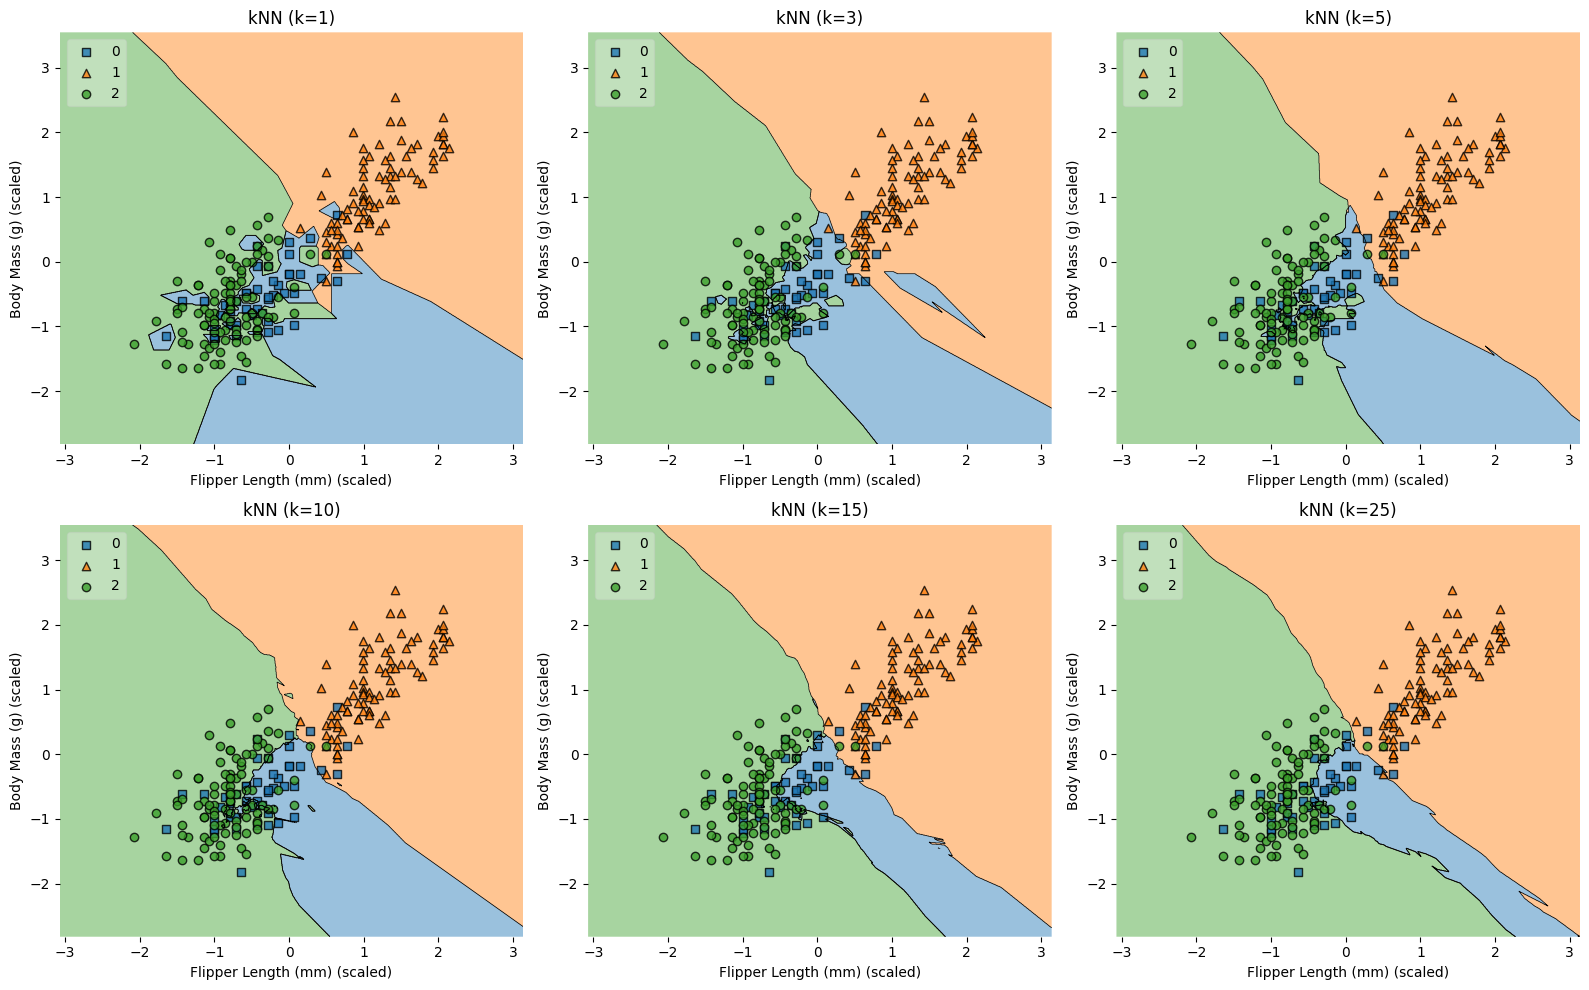

In [130]:
classifiers = []
for n_neighbors in n_neighbors_list:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    classifiers.append(knn)
gs = gridspec.GridSpec(2, 3)
fig = plt.figure(figsize=(16, 10))

titles = [
    f"kNN (k={n})" for n in n_neighbors_list
]

for clf, title, (row, col) in zip(classifiers, titles, itertools.product([0, 1], [0, 1, 2])):
    ax = plt.subplot(gs[row, col])
    plot_decision_regions(
        X=X_train_scaled, 
        y=y_train.values, 
        clf=clf, 
        legend=2, 
        ax=ax
    )
    plt.title(title)
    plt.xlabel("Flipper Length (mm) (scaled)")
    plt.ylabel("Body Mass (g) (scaled)")
plt.tight_layout()
plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

Согласно 1.3 и 1.5 оптимально брать k = 10, так как на тестовой выборке достиигается наилучшая точность и геометрическая карта имеет наименее изрезанные края. О переобучении говорят k = 1, 3, 5, так как на обучаяющей выборке достигается наилучшая точность, в то вермя как на тесте она сильно проседает. На геометричнской карте присуствтуют области, выделенные под шумовые данные внутри каждого класса и присутствует сильная изрезанность краев. Проверим это с помощью подсчета F-бета меры.

In [35]:
from sklearn.metrics import fbeta_score
beta = 0.5 
fbeta_scores_test = []
for knn in classifiers:
    y_pred_test = knn.predict(X_test_scaled)
    fbeta_test = fbeta_score(y_test, y_pred_test, beta=beta, average='weighted')
    fbeta_scores_test.append(fbeta_test)
for n_neighbors, fbeta_test in zip(n_neighbors_list, fbeta_scores_test):
    print(f"k = {n_neighbors} f = {fbeta_test:.4f}")

k = 1 f = 0.7723
k = 3 f = 0.7708
k = 5 f = 0.7787
k = 10 f = 0.8345
k = 15 f = 0.7926
k = 25 f = 0.7790


### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

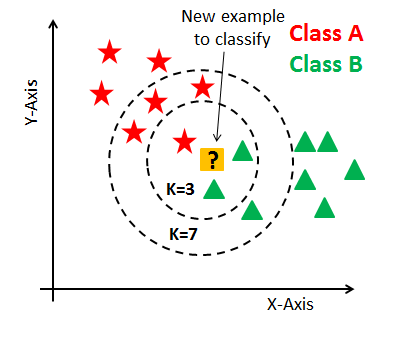

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [131]:
class KNN:
    def __init__(self, k: int):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        X = np.array(X)
        distances = np.linalg.norm(X[:, np.newaxis] - self.X_train, axis=2)
        k_indices = np.argpartition(distances, self.k, axis=1)[:, :self.k]
        k_nearest_labels = self.y_train[k_indices]
        predictions = np.array([Counter(labels).most_common(1)[0][0] for labels in k_nearest_labels])
        return predictions
    def count_distance(self, x, y):
        return np.linalg.norm(x - y)

In [132]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [133]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [134]:
k_values = [1, 3, 5, 10, 15, 25]
best_accuracy = 0
best_k = 0

for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"k={k}: Точность = {accuracy:.4f}")
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = k

k=1: Точность = 0.7347
k=3: Точность = 0.7551
k=5: Точность = 0.7653
k=10: Точность = 0.8367
k=15: Точность = 0.8061
k=25: Точность = 0.7959


### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [2]:
data = pd.read_csv('diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [136]:
missing_values = data.isnull().sum()
print("Пропущенные значения:\n", missing_values)

Пропущенные значения:
 Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64


In [3]:
data = data.drop(columns=['Unnamed: 0'])
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

In [4]:
numeric_features = data.select_dtypes(include=['float64', 'int64']).columns
numeric_data = data[numeric_features]
(numeric_data, numeric_features)

(       carat  depth  table  price     x     y     z
 0       0.23   61.5   55.0    326  3.95  3.98  2.43
 1       0.21   59.8   61.0    326  3.89  3.84  2.31
 2       0.23   56.9   65.0    327  4.05  4.07  2.31
 3       0.29   62.4   58.0    334  4.20  4.23  2.63
 4       0.31   63.3   58.0    335  4.34  4.35  2.75
 ...      ...    ...    ...    ...   ...   ...   ...
 53935   0.72   60.8   57.0   2757  5.75  5.76  3.50
 53936   0.72   63.1   55.0   2757  5.69  5.75  3.61
 53937   0.70   62.8   60.0   2757  5.66  5.68  3.56
 53938   0.86   61.0   58.0   2757  6.15  6.12  3.74
 53939   0.75   62.2   55.0   2757  5.83  5.87  3.64
 
 [53940 rows x 7 columns],
 Index(['carat', 'depth', 'table', 'price', 'x', 'y', 'z'], dtype='object'))

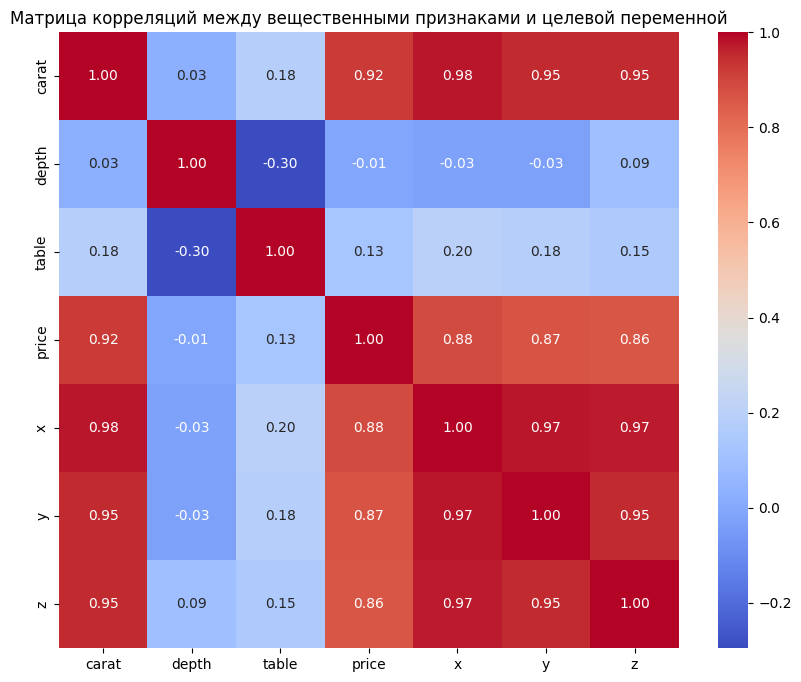

Корреляция признаков с целевой переменной (price):
carat    0.921591
x        0.884435
y        0.865421
z        0.861249
table    0.127134
depth   -0.010647
Name: price, dtype: float64


In [5]:
import seaborn as sns
correlation_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Матрица корреляций между вещественными признаками и целевой переменной")
plt.show()
price_correlations = correlation_matrix['price'].drop('price')
print("Корреляция признаков с целевой переменной (price):")
print(price_correlations.sort_values(ascending=False))

Наибольшую корреляцию имеют carat, x, y, z, price

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [6]:
categorical_features = ['cut', 'color', 'clarity']
data = pd.get_dummies(data, columns=categorical_features, drop_first=True)

In [7]:
data.head()

,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,True,False,False,...,False,False,True,False,False,True,False,False,False,False


**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3. Не забудьте про параметр `stratify`.

In [8]:
X = data.drop(columns=['price'])
y = data['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=60
)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [9]:
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])

X_test_scaled = X_test.copy()
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

Стандартизация влияет на коэффициенты линейной регрессии. Признаки теперь имеют среднее 0 и диспесию 1. Коэффициенты теперь имеют смысл изменения целевой переменной при увеличении соответствующего признака на 1 стандартное отклонение. Теперь все признаки вносят один и тот же вклад в обучение модели.

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)

y_test_pred = model.predict(X_test_scaled)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
(mse_train, mse_test)

(1269152.9157750984, 1296493.5435653813)

In [11]:
from sklearn.metrics import mean_absolute_error
def mean_absolute_percentage_error(y_true, y_pred):
    return 100 * mean_absolute_error(y_true, y_pred) / y_true.mean()
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
print(f"MAPE на обучающей выборке: {mape_train:.2f}%")
print(f"MAPE на тестовой выборке: {mape_test:.2f}%")

MAPE на обучающей выборке: 18.82%
MAPE на тестовой выборке: 18.92%


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [12]:
coefficients = model.coef_
feature_names = X_train_scaled.columns
coef_df = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients
})
coef_df['Абсолютное значение'] = coef_df['Коэффициент'].abs()
coef_df = coef_df.sort_values(by='Абсолютное значение', ascending=False)
print("Оценки коэффициентов:")
print(coef_df)
print(f"\nСвободный член (intercept): {model.intercept_:.4f}")
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']

Оценки коэффициентов:
          Признак  Коэффициент  Абсолютное значение
0           carat  5271.012754          5271.012754
16     clarity_IF  5221.301748          5221.301748
21   clarity_VVS1  4918.882316          4918.882316
22   clarity_VVS2  4876.157362          4876.157362
19    clarity_VS1  4496.761869          4496.761869
20    clarity_VS2  4179.681825          4179.681825
17    clarity_SI1  3574.314266          3574.314266
18    clarity_SI2  2604.731245          2604.731245
15        color_J -2333.023242          2333.023242
14        color_I -1438.226301          1438.226301
3               x -1136.352975          1136.352975
13        color_H  -947.550839           947.550839
7       cut_Ideal   877.878687           877.878687
8     cut_Premium   803.228946           803.228946
9   cut_Very Good   776.175144           776.175144
6        cut_Good   624.355274           624.355274
12        color_G  -457.617555           457.617555
11        color_F  -259.820460           2

Среди переменных нет таких, которые бы отличались по значениям коэффициентов на порядок, но о мультиколллинеарности говорит VIF (выведем ее ниже). Также о мультиколлинеарности говорит таблица корреляции (например, carat сильно коррелирует с x, y, z). В целом, если так можно считать, то "на порядок" превосходят carat, clarity. 

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["Признак"] = numeric_data.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_data.values, i) for i in range(numeric_data.shape[1])]
vif_data

,Признак,VIF
0,carat,103.726117
1,depth,516.456375
2,table,501.097896
3,price,13.464526
4,x,1288.946580
5,y,531.485870
6,z,543.235912


**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [15]:
from sklearn.linear_model import Lasso, Ridge
lasso = Lasso(alpha=10)
lasso.fit(X_train_scaled, y_train)
ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled, y_train)
coef_df['Lasso Коэффициент'] = lasso.coef_
coef_df['Ridge Коэффициент'] = ridge.coef_
print("Сравнение коэффициентов:")
print(coef_df[['Признак', 'Коэффициент', 'Lasso Коэффициент', 'Ridge Коэффициент']])

Сравнение коэффициентов:
          Признак  Коэффициент  Lasso Коэффициент  Ridge Коэффициент
0           carat  5271.012754        4739.645987        5224.670613
16     clarity_IF  5221.301748        -151.551956         -93.720100
21   clarity_VVS1  4918.882316         -99.492638         -54.248110
22   clarity_VVS2  4876.157362        -679.339054       -1100.669313
19    clarity_VS1  4496.761869          -0.000000          73.871389
20    clarity_VS2  4179.681825          -2.327706         -27.624208
17    clarity_SI1  3574.314266          -0.000000         645.846598
18    clarity_SI2  2604.731245         180.296857         903.706546
15        color_J -2333.023242          80.763590         825.613714
14        color_I -1438.226301         103.871582         804.079299
3               x -1136.352975           0.000000        -185.500561
13        color_H  -947.550839          -0.000000        -247.704309
7       cut_Ideal   877.878687        -108.172184        -441.239927
8     cut

Проблема мультиколлинеарности не исчезла, потому что нельзя ее уменьшить, так как карат напрямую зависит от размера бриллианта. Поэтому регуляризация не исправляет проблему мультиколлинеарности.

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

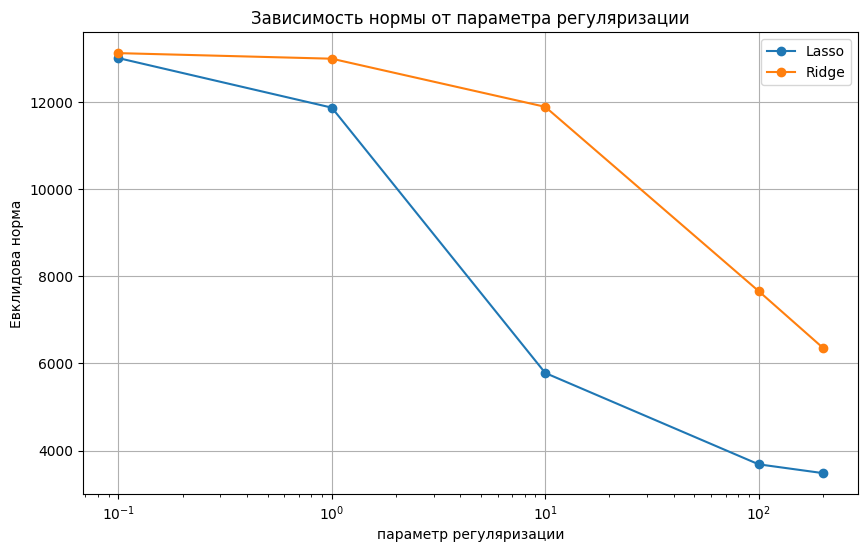

In [16]:
alphas = [0.1, 1, 10, 100, 200]
lasso_norms = []
ridge_norms = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    lasso_norms.append(np.linalg.norm(lasso.coef_))
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_norms.append(np.linalg.norm(ridge.coef_))
plt.figure(figsize=(10, 6))
plt.plot(alphas, lasso_norms, label='Lasso', marker='o')
plt.plot(alphas, ridge_norms, label='Ridge', marker='o')
plt.xscale('log')
plt.xlabel('параметр регуляризации')
plt.ylabel('Евклидова норма')
plt.title('Зависимость нормы от параметра регуляризации')
plt.legend()
plt.grid()
plt.show()

Lasso намного сильнее уменьшает коэффициенты, так как она позволяет выделять признаки, устраняя мультиколлинеарность

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [17]:
from sklearn.linear_model import LassoCV

alphas = [0.1, 1, 10, 100, 200]
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)
mean_mse = lasso_cv.mse_path_.mean(axis=1)
cv_results = pd.DataFrame({
    'Alpha': lasso_cv.alphas_,
    'Средний MSE': mean_mse
})
print("Результаты кросс-валидации:")
print(cv_results)
optimal_alpha = lasso_cv.alpha_
print(f"\nОптимальное значение alpha: {optimal_alpha}")

C:\Users\Honor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1463051047.8942375, tolerance: 47751193.00958056
  model = cd_fast.enet_coordinate_descent_gram(


Результаты кросс-валидации:
   Alpha   Средний MSE
0  200.0  2.418197e+06
1  100.0  2.207494e+06
2   10.0  1.498077e+06
3    1.0  1.276080e+06
4    0.1  1.272712e+06

Оптимальное значение alpha: 0.1


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [18]:
optimal_alpha = 0.1
final_lasso = Lasso(alpha=optimal_alpha)
final_lasso.fit(X_train_scaled, y_train)
coef_df['Lasso Коэффициент'] = final_lasso.coef_
print("Коэффициенты итоговой Lasso-регрессии:")
print(coef_df[['Признак', 'Lasso Коэффициент']])

Коэффициенты итоговой Lasso-регрессии:
          Признак  Lasso Коэффициент
0           carat        5266.127761
16     clarity_IF         -91.670730
21   clarity_VVS1         -51.928422
22   clarity_VVS2       -1125.639292
19    clarity_VS1          67.019003
20    clarity_VS2         -26.589568
17    clarity_SI1         614.689236
18    clarity_SI2         868.559490
15        color_J         793.461542
14        color_I         767.395122
3               x        -191.142840
13        color_H        -254.510435
7       cut_Ideal        -451.945889
8     cut_Premium        -941.804377
9   cut_Very Good       -1431.414429
6        cut_Good       -2324.946437
12        color_G        5165.561242
11        color_F        3522.738598
10        color_E        2553.554916
1           depth        4444.154258
4               y        4127.807235
2           table        4865.093751
5               z        4823.199403


Наиболее информативным является признак Carat, так как он по сути и определяет алмаз как таковой и от него зависит уже цена.

**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [153]:
y_pred_lasso = final_lasso.predict(X_test_scaled)
y_pred_linear = model.predict(X_test_scaled)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mse_linear = mean_squared_error(y_test, y_pred_linear)

print(f"[Lasso] MSE: {mse_lasso:.2f}")
print(f"[Linear] MSE: {mse_linear:.2f}")

if mse_lasso < mse_linear:
    print("\nLasso-регрессия лучше.")
else:
    print("\nОбычная линейная регрессия лучше.")

[Lasso] MSE: 1296844.86
[Linear] MSE: 1296493.54

Обычная линейная регрессия лучше.
